In [38]:
!pip install -q requests beautifulsoup4 openpyxl pandas numpy matplotlib plotly dash dash-bootstrap-components

In [39]:
import io
import re
import time
import warnings
from threading import Thread

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from bs4 import BeautifulSoup
from dash import Dash, dcc, html, Input, Output
import dash_bootstrap_components as dbc

warnings.filterwarnings("ignore")
print("Все библиотеки импортированы")

Все библиотеки импортированы


In [46]:
import urllib3
urllib3.disable_warnings()

HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}

print("Парсинг страницы Росстата")
resp = requests.get("https://rosstat.gov.ru/folder/11188",
                    headers=HEADERS, timeout=15, verify=False)
soup = BeautifulSoup(resp.text, "html.parser")
print(f"Статус ответа: {resp.status_code}")

links = []
for a in soup.find_all("a", href=True):
    href = a["href"]
    text = a.get_text(strip=True)
    if any(ext in href.lower() for ext in [".xlsx", ".xls"]):
        full_url = "https://rosstat.gov.ru" + href if href.startswith("/") else href
        links.append({"text": text, "url": full_url})

print(f"Найдено Excel файлов: {len(links)}")
for i, l in enumerate(links[:5]):
    print(f"  {i+1}. {l['text'][:60]}...")

Парсинг страницы Росстата
Статус ответа: 200
Найдено Excel файлов: 16
  1. XLSX...
  2. XLS...
  3. XLS...
  4. XLS...
  5. XLS...


In [41]:
import urllib3
urllib3.disable_warnings()

if len(links) > 0:
    target = links[0]
    print(f"Скачиваем: {target['text']}")
    print(f"URL: {target['url']}")

    resp2 = requests.get(target["url"], headers=HEADERS, timeout=30, verify=False)
    df_raw = pd.read_excel(io.BytesIO(resp2.content), header=None)
    print(f"Размер данных: {df_raw.shape}")
    print("\n Первые 20 строк файла:")
    print(df_raw.head(20))
else:
    print("Excel-файлы не найдены, используем демо-данные")
    df_raw = None

Скачиваем: XLSX
URL: https://rosstat.gov.ru/storage/mediabank/1-1_prod_03-2026.xlsx
Размер данных: (14, 2)

 Первые 20 строк файла:
              0                                                  1
0   Содержание:                                                NaN
1           NaN                                                NaN
2            1.  Производство основных видов импортозамещающих ...
3            2.  Производство основных видов импортозамещающих ...
4           NaN                                                NaN
5           NaN                         Ответственный исполнитель:
6           NaN                             Пешкова Ирина Ивановна
7           NaN                    8 (495) 568-00-42 (доб. 99-883)
8           NaN                                                NaN
9           NaN                                                NaN
10          NaN                                                NaN
11          NaN                                                

In [42]:
# Создаём демонстрационные данные на основе статистики МСП
df = pd.DataFrame({
    "Год": [2017, 2018, 2019, 2020, 2021, 2022, 2023],
    "Малые": [2703, 2863, 2680, 2378, 2572, 2668, 2750],
    "Микро": [5560, 5830, 5680, 5200, 5600, 5750, 5820],
    "Средние": [19.3, 19.6, 18.8, 17.2, 18.1, 18.4, 18.0],
    "Работников": [11.5, 11.8, 11.4, 10.6, 11.1, 11.3, 11.6],
    "Оборот_трлн": [38.9, 42.1, 43.5, 38.2, 45.8, 49.3, 52.1],
})

print("Данные готовы:")
print(df.to_string(index=False))

Данные готовы:
 Год  Малые  Микро  Средние  Работников  Оборот_трлн
2017   2703   5560     19.3        11.5         38.9
2018   2863   5830     19.6        11.8         42.1
2019   2680   5680     18.8        11.4         43.5
2020   2378   5200     17.2        10.6         38.2
2021   2572   5600     18.1        11.1         45.8
2022   2668   5750     18.4        11.3         49.3
2023   2750   5820     18.0        11.6         52.1


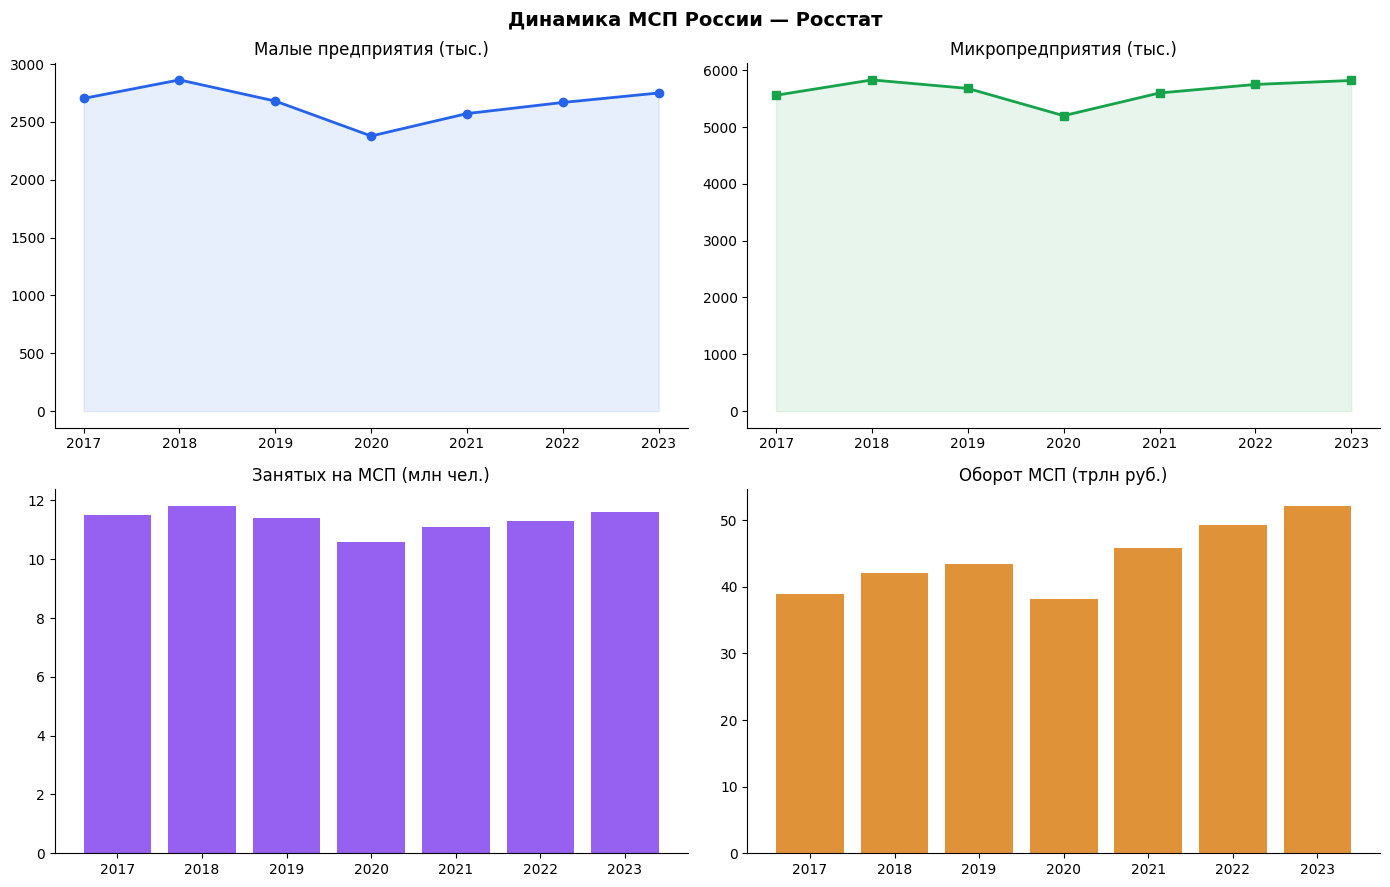

Статические графики построены


In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Малые предприятия
axes[0, 0].plot(df["Год"], df["Малые"], marker="o", color="#2563EB", linewidth=2)
axes[0, 0].fill_between(df["Год"], df["Малые"], alpha=0.1, color="#2563EB")
axes[0, 0].set_title("Малые предприятия (тыс.)")
axes[0, 0].spines[["top", "right"]].set_visible(False)

# Микропредприятия
axes[0, 1].plot(df["Год"], df["Микро"], marker="s", color="#16A34A", linewidth=2)
axes[0, 1].fill_between(df["Год"], df["Микро"], alpha=0.1, color="#16A34A")
axes[0, 1].set_title("Микропредприятия (тыс.)")
axes[0, 1].spines[["top", "right"]].set_visible(False)

# Занятые на МСП
axes[1, 0].bar(df["Год"], df["Работников"], color="#7C3AED", alpha=0.8)
axes[1, 0].set_title("Занятых на МСП (млн чел.)")
axes[1, 0].spines[["top", "right"]].set_visible(False)

# Оборот МСП
axes[1, 1].bar(df["Год"], df["Оборот_трлн"], color="#D97706", alpha=0.8)
axes[1, 1].set_title("Оборот МСП (трлн руб.)")
axes[1, 1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Динамика МСП России — Росстат", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("Статические графики построены")

In [47]:
from functools import lru_cache

# кэширование
@lru_cache(maxsize=32)
def get_cached_df(year_min, year_max):
    """Кэширует отфильтрованные данные"""
    return df[(df["Год"] >= year_min) & (df["Год"] <= year_max)].to_dict()

# создание дэшборда
app = Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

app.layout = dbc.Container([
    html.H4("Динамика МСП России", className="mt-3 mb-3"),

    # KPI карточки(интерактивность)
    dbc.Row([
        dbc.Col(dbc.Card(dbc.CardBody([
            html.H6("Малые", className="text-muted"),
            html.H3(f"{df['Малые'].iloc[-1]:,.0f}", style={"color": "#2563EB"}),
        ]), className="text-center shadow-sm"), md=3),
        dbc.Col(dbc.Card(dbc.CardBody([
            html.H6("Микро", className="text-muted"),
            html.H3(f"{df['Микро'].iloc[-1]:,.0f}", style={"color": "#16A34A"}),
        ]), className="text-center shadow-sm"), md=3),
        dbc.Col(dbc.Card(dbc.CardBody([
            html.H6("Занятые", className="text-muted"),
            html.H3(f"{df['Работников'].iloc[-1]:.1f} млн", style={"color": "#D97706"}),
        ]), className="text-center shadow-sm"), md=3),
        dbc.Col(dbc.Card(dbc.CardBody([
            html.H6("Оборот", className="text-muted"),
            html.H3(f"{df['Оборот_трлн'].iloc[-1]:.1f} трлн", style={"color": "#7C3AED"}),
        ]), className="text-center shadow-sm"), md=3),
    ], className="mb-3"),

    # Фильтры
    dbc.Row([
        dbc.Col([
            html.Label("Показатель"),
            dcc.Dropdown(id="metric", options=[
                {"label": "Малые", "value": "Малые"},
                {"label": "Микро", "value": "Микро"},
                {"label": "Средние", "value": "Средние"},
                {"label": "Занятые", "value": "Работников"},
                {"label": "Оборот", "value": "Оборот_трлн"},
            ], value="Малые", clearable=False),
        ], md=4),
        dbc.Col([
            html.Label("Диапазон лет"),
            dcc.RangeSlider(id="year-range",
                min=df["Год"].min(), max=df["Год"].max(), step=1,
                value=[df["Год"].min(), df["Год"].max()],
                marks={y: str(y) for y in df["Год"].unique()}),
        ], md=6),
        dbc.Col([
            html.Label("Тип графика"),
            dcc.RadioItems(id="chart-type",
                options=[
                    {"label": " Линии", "value": "line"},
                    {"label": " Столбцы", "value": "bar"},
                ], value="line", inline=True),
        ], md=2),
    ], className="mb-3"),

    # Графики
    dbc.Row([
        dbc.Col(dcc.Graph(id="main-chart"), md=8),
        dbc.Col(dcc.Graph(id="trend-chart"), md=4),
    ], className="mb-3"),

    # Выводы
    dbc.Card(dbc.CardBody([
        html.H6("Аналитика", className="mb-2"),
        html.Div(id="insights", style={"fontSize": "13px"})
    ]), className="bg-light"),
], fluid=True)

# коллбэк
@app.callback(
    Output("main-chart", "figure"),
    Output("trend-chart", "figure"),
    Output("insights", "children"),
    Input("metric", "value"),
    Input("year-range", "value"),
    Input("chart-type", "value"),
)
def update_charts(metric, year_range, chart_type):
    year_min, year_max = year_range

    # Берём данные из кэша
    filtered_df = pd.DataFrame(get_cached_df(year_min, year_max))

    if filtered_df.empty:
        return {}, {}, "Нет данных"

    # Основной график
    if chart_type == "line":
        fig = px.line(filtered_df, x="Год", y=metric, markers=True,
                      template="plotly_white", title=f"{metric} по годам")
        fig.update_traces(line_color="#2563EB", line_width=2)
    else:
        fig = px.bar(filtered_df, x="Год", y=metric,
                     template="plotly_white", title=f"{metric} по годам")
        fig.update_traces(marker_color="#7C3AED")
    fig.update_layout(height=400, margin=dict(l=10, r=10, t=40, b=10))

    # Трендовый график
    filtered_df["Рост"] = filtered_df[metric].pct_change() * 100
    trend = px.bar(filtered_df, x="Год", y="Рост",
                   template="plotly_white", title="Темп роста (%)")
    trend.update_traces(marker_color="#16A34A")
    trend.update_layout(height=400, margin=dict(l=10, r=10, t=40, b=10))

    # Выводы
    current = filtered_df[metric].iloc[-1]
    first = filtered_df[metric].iloc[0]
    growth = ((current - first) / first) * 100
    insights = html.Ul([
        html.Li(f"{metric}: {current:,.1f} (за {int(year_min)}-{int(year_max)})"),
        html.Li(f"Рост: {growth:+.1f}%"),
    ], className="mb-0")

    return fig, trend, insights

print("Дашборд с кэшированием создан")

Дашборд с кэшированием создан


In [45]:
import time
from threading import Thread
import requests
import nest_asyncio

nest_asyncio.apply()

def run_server():
    app.run_server(host='0.0.0.0', port=8051, debug=False, use_reloader=False)

Thread(target=run_server, daemon=True).start()

for i in range(20):
    try:
        requests.get("http://127.0.0.1:8051", timeout=1)
        print(f"Сервер запущен")
        break
    except:
        time.sleep(1)

# Получаем и показываем ссылку
from google.colab import output
url = output.eval_js(f"google.colab.kernel.proxyPort(8051)")
print(f"\nССЫЛКА НА ДАШБОРД: {url}")

# Встраиваем iframe
output.serve_kernel_port_as_iframe(8051, height=750)

print("\nДашборд готов")

Exception in thread Thread-7 (run_server):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_3155/3780420424.py", line 9, in run_server
  File "/usr/local/lib/python3.12/dist-packages/dash/_obsolete.py", line 22, in __getattr__
    raise err.exc(err.message)
dash.exceptions.ObsoleteAttributeException: app.run_server has been replaced by app.run



ССЫЛКА НА ДАШБОРД: https://8051-m-s-kkb-usc1c1-sn9x27km82lk-c.us-central1-1.prod.colab.dev


<IPython.core.display.Javascript object>


Дашборд готов
